In [ ]:
#ORIGINAL RUN

In [ ]:
#####################
#Loading Packages and Reading Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr; import time as time

data=xr.open_dataset('/mnt/lustre/koa/koastore/torri_group/air_directory/cm1r20.3/run/cm1out_test7tundra-7_062217.nc')
parcel=xr.open_dataset('/mnt/lustre/koa/koastore/torri_group/air_directory/cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc')

In [2]:
# #TESTING TESTING TESTING
# #TESTING #TESTING ***
# data=data.isel(time=slice(0,10),zh=slice(0,5),zf=slice(0,5))
# parcel=parcel.isel(time=slice(0,10),xh=slice(0,10)) #100 parcels, 10 ts

# x_data=parcel['x'].data
# y_data=parcel['y'].data
# z_data=parcel['z'].data

# #TEST DATA SET
# parcel['x'].values[0:10, 0:10] = -250525
# parcel['y'].values[0:10, 0:10] = -44525

# # Modify 'z' variable
# parcel['z'].values[0:5, 0:5] = 200
# parcel['z'].values[0:5, 5:10] = 200
# parcel['z'].values[5:10, 0:5] = 80
# parcel['z'].values[5:10, 5:10] = 300

# data['w'].values[0:5]=0
# data['qc'].values[0:5]=0
# data['w'].values[5:10]=10
# data['qc'].values[5:10]=10

In [5]:
###################################################
# Functions

In [3]:
#constants
Cp=1004 #Jkg-1K-1
Cv=717 #Jkg-1K-1
Rd=Cp-Cv #Jkg-1K-1
eps=0.608

Lx=data['xf'][-1].item()-data['xf'][0].item() #x length (km)
Ly=data['yf'][-1].item()-data['yf'][0].item() #y length (km)
Np=len(parcel['xh']) #number of lagrangian parcles
dt=data['time'][1].item()/1e9 #sec
dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
xs=data['xf'].values*1000
ys=data['yf'].values*1000
zs=data['zf'].values*1000

def zf(z):
    k=z #z is the # level of z
    out=data['zf'].values[k]*1000
    return out
# def rho(x,y,z,t):
#     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
#     p0=101325 #Pa
#     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
#     T=theta*(p/p0)**(Rd/Cp)
#     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
#     # Tv=T*(1+eps*qv)
#     Tv=T*(eps+qv)/(eps*(1+qv))
#     rho = p/(Rd*Tv)
#     out=rho
#     return out
rho_data=data['rho'].data
def rho(x,y,z,t):
    # out=data['rho'].isel(xh=x,yh=y,zh=z,time=t).item()
    out=rho_data[t,z,y,x]
    return out
def m(t):
    m=0
    #triple sum
    for k in range(len('zh')):
        for j in range(len('yh')):
            for i in range(len('xh')):
                rho_out=rho(i,j,k,t)
                m+=rho_out*(zf(k+1)-zf(k))
    #triple sum
    m=m*dx*dy/Np
    out=m
    return out

Text(0, 0.5, 'm(t) (kg/parcel)')

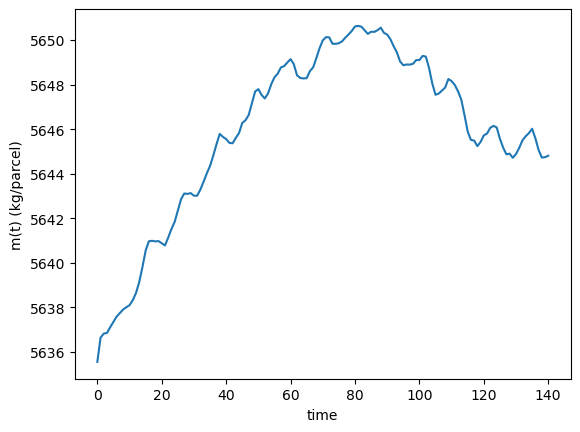

In [65]:
# ts=np.arange(len(data['time']))
# ms=[]
# for ind in ts:
#     ms.append(m(ind))

# plt.plot(ts,ms);plt.xlabel('time');plt.ylabel('m(t) (kg/parcel)')

In [4]:
#Define Indicator Functions
if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    # variable='th'; th_data=data[variable].data # get qc data
    # variable='buoyancy'; buoyancy_data=data[variable].data # get qc data

    x_data=parcel['x'].data
    y_data=parcel['y'].data
    z_data=parcel['z'].data
    print('done loading')
    emptylike=True


def A_ind3d(i,t):
    #1s or 0s if parcel evaluates threshold for ith parcel at time t

    #(x,y,z) eulerian grid location
    # x=parcel['x'].isel(time=t,xh=i).values
    # y=parcel['y'].isel(time=t,xh=i).values
    # z=parcel['z'].isel(time=t,xh=i).values

    x=x_data[t,i]
    y=y_data[t,i]
    z=z_data[t,i]
    # xh_val=data['xh'].values*1000; which_xh=np.searchsorted(xh_val,x)-1; which_xh=np.where(which_xh == -1, 0, which_xh) #finds which xh layer parcel in
    # yh_val=data['yh'].values*1000; which_yh=np.searchsorted(yh_val,y)-1; which_xh=np.where(which_xh == -1, 0, which_xh) #finds which yh layer parcel in
    ybins=data['yf'].values*1000; dy=ybins[1]-ybins[0];which_y=np.floor(y/dy).astype(int)+np.where(data['yf']==0)[0].item()
    xbins=data['xf'].values*1000; dx=xbins[1]-xbins[0];which_x=np.floor(x/dx).astype(int)+np.where(data['xf']==0)[0].item()
    zf_val=data['zf'].values*1000; which_z=np.searchsorted(zf_val,z)-1; which_z=np.where(which_z == -1, 0, which_z) #finds which zf layer parcel in 

    
    #Data
    # qc=data['qc'].isel(time=t,xh=which_x,yh=which_y,zh=which_z).values
    # qi=data['qi'].isel(time=t,xh=which_x,yh=which_y,zh=which_z).values
    # w=data['w'].isel(time=t).interp(zf=data['zh']).isel(xh=which_x,yh=which_y,zh=which_z).values
    qc=qc_data[t,which_z,which_y,which_x]
    qi=qi_data[t,which_z,which_y,which_x]
    w=w_data[t,which_z,which_y,which_x]

    #Threshholds
    qcqi_thresh=1e-6 #kg/kg
    w_thresh=0.1 #1 #m/s
    
    A=np.where((w > w_thresh), 1, 0).item() #general updraft
    # A=np.where((qc + qi > qcqi_thresh) & (w > w_thresh), 1, 0).item() #cloudy updraft

    # if A==1: print(f'qc+qi: {qc+qi}',f'w: {w}') #TESTING***
    return A 
    
def I_ind3d(x,y,z,i,t): #z interval indictator function 
    k=z
    dz=zf(k+1)-zf(k)
    Ix=[xs[x]-dx/2,xs[x]+dx/2]
    Iy=[ys[y]-dy/2,ys[y]+dy/2]    
    Iz=[zs[z]-dz/2,zs[z]+dz/2]
    # X=parcel['x'].isel(xh=i,time=t)
    # Y=parcel['y'].isel(xh=i,time=t)
    # Z=parcel['z'].isel(xh=i,time=t)
    X=x_data[t,i]
    Y=y_data[t,i]
    Z=z_data[t,i]

    if (Ix[0] <= X <= Ix[1]) & (Iy[0] <= Y <= Iy[1]) & (Iz[0] <= Z <= Iz[1]):
        out=1
    else: 
        out=0
    return out

def which_parcel3d(x,y,z,t): #finds which parcels are in the gridbox at time t 
    # X=parcel['x'].isel(time=t).values
    # Y=parcel['y'].isel(time=t).values
    # Z=parcel['z'].isel(time=t).values
    X=x_data[t]
    Y=y_data[t]
    Z=z_data[t]

    dz=zf(z+1)-zf(z)
    Ix=[xs[x]-dx/2,xs[x]+dx/2]
    Iy=[ys[y]-dy/2,ys[y]+dy/2]    
    Iz=[zs[z]-dz/2,zs[z]+dz/2]

    # X[:]=Ix[0];Y[:]=Iy[0];Z[:]=Iz[0] #TESTING
    # print(Ix,Iy,Iz) #TESTING

    out=np.where((X >= Ix[0]) & (X <= Ix[1]) &
                 (Y >= Iy[0]) & (Y <= Iy[1]) & 
                 (Z >= Iz[0]) & (Z <= Iz[1]))
    return out

def H_ind_e(x): #Heaviside unit step function
    if x>0:
        out=1
    else:
        out=0 
    return out
    
def H_ind_d(x): #Heaviside unit step function
    if x<0:
        out=-1
    else:
        out=0 
    return out

def H_ind_m(x): #Heaviside unit step function
    if x>0:
        out=1
    elif x<0:
        out=-1 #why not allow for negative entrainement (detrainment)
    elif x==0: 
        out=0
    return out

loading neccessary variables
done loading


In [5]:
#Calculating 3-Dimensional Entrainment Rate (KYONGMIN YEO AND DAVID M. ROMPS 2012)
#In the Lagrangian framework, the local entrainment rate e(x, t) is the number of particles that switch from inactive to active in each grid cell over some averaging time
def e3d(x,y,z,t): #horizontal averaged entrainment rate
    m_out=m(t)
    dz=zf(z+1)-zf(z)
    constant=(m_out/dx/dy/dz/dt) 

    #subsets only parcel that are entrainment candidates
    one=which_parcel3d(x,y,z,t) #checks if parcel is in the box at time t,
    # which_parcel_out=one[0]
    two=which_parcel3d(x,y,z,t-1) 
    which_parcel_out=(one or two)[0]

    # print(which_parcel_out)
    
    out=0 #initialize output
    # for i in range(Np):
    for i in which_parcel_out:
        if np.mod(i,5000)==0: print(f'{i}/{Np}')
        A1=A_ind3d(i,t);A2=A_ind3d(i,t-1); 
        H=H_ind_e(A1-A2)
        I=I_ind3d(x,y,z,i,t)
        out+=constant*H*I

        # print('A1','A2','H','I');print(A1,A2,H,I);print('-'*40); #TESTING***
        # print(f'entrainment: {out}')
    return out #num/s

def d3d(x,y,z,t): #horizontal averaged entrainment rate
    m_out=m(t)
    dz=zf(z+1)-zf(z)
    constant=(m_out/dx/dy/dz/dt) 

    #subsets only parcel that are entrainment candidates
    one=which_parcel3d(x,y,z,t) #checks if parcel is in the box at time t,
    # which_parcel_out=one[0]
    two=which_parcel3d(x,y,z,t-1) 
    which_parcel_out=(one or two)[0]
    
    out=0 #initialize output
    # for i in range(Np):
    for i in which_parcel_out:
        if np.mod(i,5000)==0: print(f'{i}/{Np}')
        A1=A_ind3d(i,t);A2=A_ind3d(i,t-1); 
        H=H_ind_d(A1-A2)
        I=I_ind3d(x,y,z,i,t)
        out+=constant*H*I

        # print('A1','A2','H','I');print(A1,A2,H,I);print('-'*40); #TESTING***
        # print(f'entrainment: {out}')
    return out #num/s

def m3d(x,y,z,t): #horizontal averaged entrainment rate
    m_out=m(t)
    dz=zf(z+1)-zf(z)
    constant=(m_out/dx/dy/dz/dt) 

    #subsets only parcel that are entrainment candidates
    one=which_parcel3d(x,y,z,t) #checks if parcel is in the box at time t,
    # which_parcel_out=one[0]
    two=which_parcel3d(x,y,z,t-1) 
    which_parcel_out=(one or two)[0]
    
    out=0 #initialize output
    # for i in range(Np):
    for i in which_parcel_out:
        if np.mod(i,5000)==0: print(f'{i}/{Np}')
        A1=A_ind3d(i,t);A2=A_ind3d(i,t-1); 
        H=H_ind_m(A1-A2)
        I=I_ind3d(x,y,z,i,t)
        out+=constant*H*I

        # print('A1','A2','H','I');print(A1,A2,H,I);print('-'*40); #TESTING***
        # print(f'entrainment: {out}')
    return out #num/s

# # TESTING e3d()
# x=5
# y=5
# z=1 #parcels moved from 2 to 1,3
# t=5
# e3d(x=x,y=y,z=z,t=t)

In [6]:
# # TESTING TESTING TESTING

# #Making vertical profile of cloudy updrafts

# def entrainment_profile(type):
#     global w_thresh
#     #thresholds
#     w_thresh=0.1
#     qcqithresh=1e-6

#     nt=len(data['time'])
        
#     #get qc and interpolated w 

#     # finds regions that match the threshold
#     if type=="general":
#         where_updraft=np.where((w_data>=w_thresh)) #uncomment for "general updraft"
#     elif type=='cloudy': 
#         where_updraft=np.where((w_data>=w_thresh) & (qc_plus_qi>=qcqithresh)) #uncomment for "cloudy updraft" 
    
#     #creates profile storage and adds z column    
#     zhs=data['zh'].values
#     profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
#     profile_array[:,2]=zhs

#     #get incidies associated with threshold mask
#     t_ind, z_ind, y_ind, x_ind = where_updraft
    

#     #bin masked values by z level
#     for count,(th,kh,jh,ih) in enumerate(zip(t_ind,z_ind,y_ind,x_ind)):
#         if np.mod(count,100)==0: print(f'{count*100/len(t_ind):.2f} %')
#         value=e3d(ih,jh,kh,th)
#         profile_array[kh,0]+=value #adds data to first column
#         if value!=0:
#             profile_array[kh,1]+=1 #adds +1 counter to 2nd column #counter isn't of any importance currently
        
#     return profile_array

0.00 %
0.01 %
0.02 %
0.03 %
0.04 %
0.05 %
0.06 %
0.07 %
0.08 %
0.09 %
0.10 %
0.11 %
0.12 %
0.13 %
0.14 %
0.15 %
0.16 %
0.17 %
0.18 %
0.19 %
0.20 %
0.21 %
0.21 %
0.22 %
0.23 %
0.24 %
0.25 %
0.26 %
0.27 %
0.28 %
0.29 %
0.30 %
0.31 %
0.32 %
0.33 %
0.34 %
0.35 %
0.36 %
0.37 %
0.38 %
0.39 %
0.40 %
0.41 %
0.42 %
0.43 %
0.44 %
0.45 %
0.46 %
0.47 %
0.48 %
0.49 %
0.50 %
0.51 %
0.52 %
0.53 %
0.54 %
0.55 %
0.56 %
0.57 %
0.58 %
0.59 %
0.60 %
0.61 %
0.62 %
0.62 %
0.63 %
0.64 %
0.65 %
0.66 %
0.67 %
0.68 %
0.69 %
0.70 %
0.71 %
0.72 %
0.73 %
0.74 %
0.75 %
0.76 %
0.77 %
0.78 %
0.79 %
0.80 %
0.81 %
0.82 %
0.83 %
0.84 %
0.85 %
0.86 %
0.87 %
0.88 %
0.89 %
0.90 %
0.91 %
0.92 %
0.93 %
0.94 %
0.95 %
0.96 %
0.97 %
0.98 %
0.99 %
1.00 %
1.01 %
1.02 %
1.03 %
1.04 %
1.04 %
1.05 %
1.06 %
1.07 %
1.08 %
1.09 %
1.10 %
1.11 %
1.12 %
1.13 %
1.14 %
1.15 %
1.16 %
1.17 %
1.18 %
1.19 %
1.20 %
1.21 %
1.22 %
1.23 %
1.24 %
1.25 %
1.26 %
1.27 %
1.28 %
1.29 %
1.30 %
1.31 %
1.32 %
1.33 %
1.34 %
1.35 %
1.36 %
1.37 %
1.38 %
1.39 %

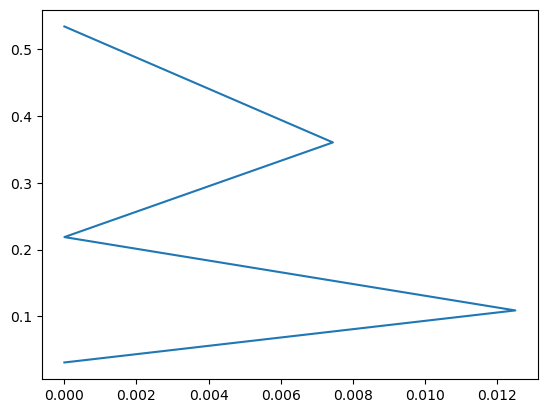

In [7]:
e_profile=entrainment_profile('cloudy')
print(e_profile)
plt.plot(e_profile[:,0],e_profile[:,2])

In [7]:
###################################################
#APPLICATION

In [8]:
####################################################
#Eulerian Updraft Profiles

In [68]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/Project/'
netCDF=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))

In [33]:
#Making vertical profile of cloudy updrafts

def entrainment_profile(type):
    global w_thresh
    #thresholds
    w_thresh=0.1 #1 #m/s
    qcqithresh=1e-6 #kg/kg

    nt=len(data['time'])
        
    #get qc and interpolated w 

    # finds regions that match the threshold
    if type=="general":
        where_updraft=np.where((w_data>=w_thresh)) #uncomment for "general updraft"
    elif type=='cloudy': 
        where_updraft=np.where((w_data>=w_thresh) & (qc_plus_qi>=qcqithresh)) #uncomment for "cloudy updraft" 
    
    #creates profile storage and adds z column    
    zhs=data['zh'].values
    profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs

    #get incidies associated with threshold mask
    t_ind, z_ind, y_ind, x_ind = where_updraft

    #bin masked values by z level
    for count,(th,kh,jh,ih) in enumerate(zip(t_ind,z_ind,y_ind,x_ind)):
        if np.mod(count,100)==0: print(f'{count*100/len(t_ind):.2f} %')
        value=e3d(ih,jh,kh,th)
        profile_array[kh,0]+=value #adds data to first column
        if value!=0:
            profile_array[kh,1]+=1 #adds +1 counter to 2nd column
        
    return profile_array

In [ ]:
print('running general entrainment profile'); e_profile=entrainment_profile('general')
# print('running cloudy entrainment profile'); e_profile=entrainment_profile('cloudy');
np.save(dir+'tracking_algorithms/ENTRAINMENT_PROFILE_Updraft_Entrain.npy', e_profile)
# np.save(dir+'tracking_algorithms/ENTRAINMENT_PROFILE_Cloudy_Entrain.npy', e_profile)

In [13]:
#Loading back in
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/Project/'
# e_profile=np.load(dir+'tracking_algorithms/ENTRAINMENT_PROFILE_Updraft_Entrain.npy') #updraft
e_profile=np.load(dir+'tracking_algorithms/ENTRAINMENT_PROFILE_Cloudy_Entrain.npy') #cloudy updraft


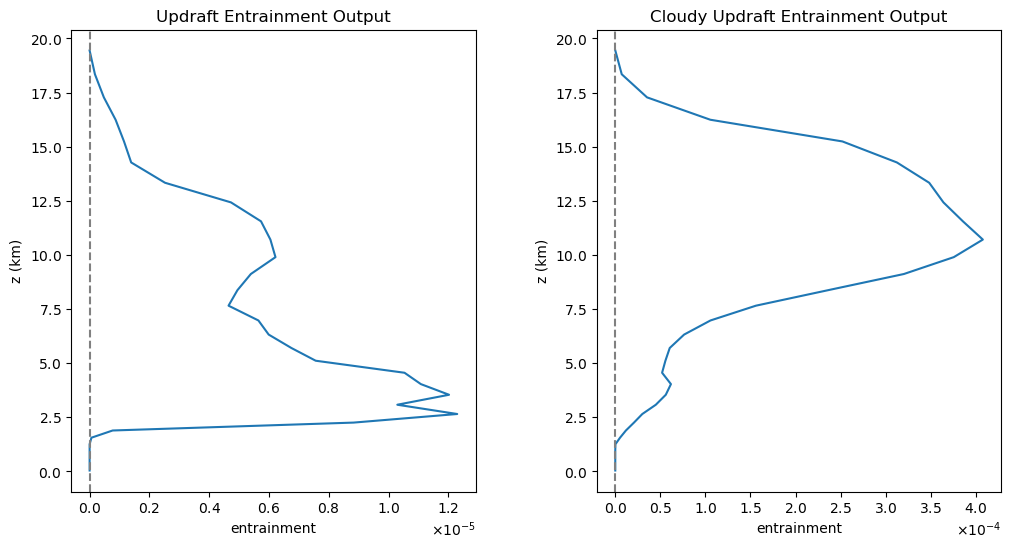

In [33]:
# def averaged_profiles(profile):
#     out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
#     out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
#     return out_var
# avg=averaged_profiles(e_profile)
# plt.plot(avg[:,0],avg[:,1])



import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np

# Directory for loading data
dir = '/mnt/lustre/koa/koastore/torri_group/air_directory/'

# Load data
e_profile_updraft = np.load(dir + 'tracking_algorithms/ENTRAINMENT_PROFILE_Updraft_Entrain.npy')  # updraft
e_profile_cloudy = np.load(dir + 'tracking_algorithms/ENTRAINMENT_PROFILE_Cloudy_Entrain.npy')  # cloudy updraft

# Create the gridspec layout
fig = plt.figure(figsize=(12, 6))  # Define the overall figure size
gs = fig.add_gridspec(1, 2, wspace=0.3)  # Create 1 row, 2 columns, adjust spacing

# Plot 1: Updraft Entrainment
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(e_profile_updraft[:, 0], e_profile_updraft[:, 2])
ax1.axvline(0, linestyle='dashed', color='gray')
ax1.set_ylabel('z (km)')
ax1.set_xlabel('entrainment')
ax1.set_title('Updraft Entrainment Output')
# ax1.set_xlim(right=4.5e-4)

# Apply scientific notation formatting
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))
ax1.xaxis.set_major_formatter(formatter)
ax1.yaxis.set_major_formatter(formatter)

# Plot 2: Cloudy Updraft Entrainment
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(e_profile_cloudy[:, 0], e_profile_cloudy[:, 2])
ax2.axvline(0, linestyle='dashed', color='gray')
ax2.set_ylabel('z (km)')
ax2.set_xlabel('entrainment')
ax2.set_title('Cloudy Updraft Entrainment Output')
# ax2.set_xlim(right=4.5e-4)

# Apply scientific notation formatting
ax2.xaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

# Show the plot
plt.show()


In [18]:
e_profile

array([[0.00000000e+00, 0.00000000e+00, 3.10000014e-02],
       [0.00000000e+00, 0.00000000e+00, 1.08946674e-01],
       [0.00000000e+00, 0.00000000e+00, 2.18786672e-01],
       [0.00000000e+00, 0.00000000e+00, 3.60520035e-01],
       [0.00000000e+00, 0.00000000e+00, 5.34146726e-01],
       [0.00000000e+00, 0.00000000e+00, 7.39666760e-01],
       [0.00000000e+00, 0.00000000e+00, 9.77080107e-01],
       [1.97925473e-07, 3.00000000e+00, 1.24638677e+00],
       [5.27934660e-06, 8.90000000e+01, 1.54758680e+00],
       [1.18029499e-05, 2.17000000e+02, 1.88068032e+00],
       [2.07429868e-05, 4.13000000e+02, 2.24566674e+00],
       [2.99945696e-05, 6.51000000e+02, 2.64254689e+00],
       [4.49859219e-05, 1.04700000e+03, 3.07132053e+00],
       [5.60362992e-05, 1.40900000e+03, 3.53198695e+00],
       [6.17423006e-05, 1.64100000e+03, 4.02454710e+00],
       [5.19314478e-05, 1.47000000e+03, 4.54900074e+00],
       [5.56165582e-05, 1.66900000e+03, 5.10534811e+00],
       [6.04096459e-05, 1.89600

In [ ]:
# #DETRAINMENT
# def detrainment_profile(type):
#     global w_thresh
#     #thresholds
#     w_thresh=0.1 #1 #m/s
#     qcqithresh=1e-6 #kg/kg

#     nt=len(data['time'])
        
#     #get qc and interpolated w 

#     # finds regions that match the threshold
#     if type=="general":
#         where_updraft=np.where((w_data>=w_thresh)) #uncomment for "general updraft"
#     elif type=='cloudy': 
#         where_updraft=np.where((w_data>=w_thresh) & (qc_plus_qi>=qcqithresh)) #uncomment for "cloudy updraft" 
    
#     #creates profile storage and adds z column    
#     zhs=data['zh'].values
#     profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
#     profile_array[:,2]=zhs

#     #get incidies associated with threshold mask
#     t_ind, z_ind, y_ind, x_ind = where_updraft
    

#     #bin masked values by z level
#     for count,(th,kh,jh,ih) in enumerate(zip(t_ind,z_ind,y_ind,x_ind)):
#         if np.mod(count,100)==0: print(f'{count*100/len(t_ind):.2f} %')
#         value=d3d(ih,jh,kh,th)
#         profile_array[kh,0]+=value #adds data to first column
#         profile_array[kh,1]+=1 #adds +1 counter to 2nd column
        
#     return profile_array

In [ ]:
# d_profile=detrainment_profile('cloudy')
# np.save(dir+'tracking_algorithms/DETRAINMENT_PROFILE_TEST.npy', e_profile)

In [ ]:
# #Loading back in
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/Project/'
# d_profile=np.load(dir+'tracking_algorithms/DETRAINMENT_PROFILE_TEST.npy')

In [ ]:
# def averaged_profiles(profile):
#     out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
#     out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
#     return out_var
# avg=averaged_profiles(d_profile)
# plt.plot(avg[:,0],avg[:,1])
# plt.axvline(0,linestyle='dashed')
# plt.ylabel('z (km)');plt.xlabel('detrainment');plt.title('cloudy updraft detrainment output')

In [ ]:
#MIXED ENTRAINMENT DETRAINMENT

In [ ]:
# #Making vertical profile of cloudy updrafts

# def mixed_profile(type):
#     global w_thresh
#     #thresholds
#     w_thresh=1
#     qcqithresh=1e-6

#     nt=len(data['time'])
        
#     #get qc and interpolated w 

#     # finds regions that match the threshold
#     if type=="general":
#         where_updraft=np.where((w_data>=w_thresh)) #uncomment for "general updraft"
#     elif type=='cloudy': 
#         where_updraft=np.where((w_data>=w_thresh) & (qc_plus_qi>=qcqithresh)) #uncomment for "cloudy updraft" 
    
#     #creates profile storage and adds z column    
#     zhs=data['zh'].values
#     profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
#     profile_array[:,2]=zhs

#     #get incidies associated with threshold mask
#     t_ind, z_ind, y_ind, x_ind = where_updraft
    

#     #bin masked values by z level
#     for count,(th,kh,jh,ih) in enumerate(zip(t_ind,z_ind,y_ind,x_ind)):
#         if np.mod(count,100)==0: print(f'{count*100/len(t_ind):.2f} %')
#         value=m3d(ih,jh,kh,th)
#         profile_array[kh,0]+=value #adds data to first column
#         if value!=0:
#             profile_array[kh,1]+=1 #adds +1 counter to 2nd column
        
#     return profile_array

In [ ]:
e_profile=mixed_profile('cloudy')
# np.save(dir+'tracking_algorithms/ENTRAINMENT_PROFILE_Updraft_Entrain.npy', e_profile)
np.save(dir+'tracking_algorithms/ENTRAINMENT_PROFILE_Updraft_Mixed.npy', e_profile)

In [23]:
e_profile=np.load(dir+'tracking_algorithms/ENTRAINMENT_PROFILE_Updraft_Mixed.npy') #updraft

Text(0.5, 1.0, 'updraft mixed entrainment-detrainment output')

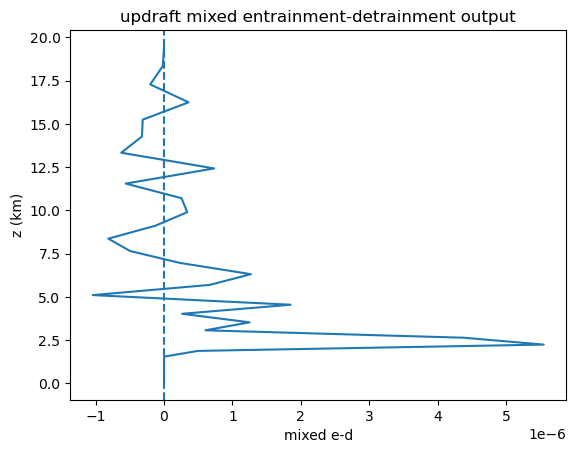

In [24]:
# def averaged_profiles(profile):
#     out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
#     out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
#     return out_var
# avg=averaged_profiles(e_profile)
# plt.plot(avg[:,0],avg[:,1])
plt.plot(e_profile[:,0],e_profile[:,2])
plt.axvline(0,linestyle='dashed')
# plt.ylabel('z (km)');plt.xlabel('entrainment');plt.title('updraft entrainment output')
plt.ylabel('z (km)');plt.xlabel('mixed e-d');plt.title('updraft mixed entrainment-detrainment output')

In [ ]:
# #VECTORIZED TESTING 
# #Incorrect because cant know where the parcel came from (cloudy at time t and noncloudy at time t-1)
# import numpy as np
# import matplotlib.pyplot as plt
# import xarray as xr; import time as time
# data=xr.open_dataset('/mnt/lustre/koa/koastore/torri_group/air_directory/cm1r20.3/run/cm1out_test7tundra-7_062217.nc')
# parcel=xr.open_dataset('/mnt/lustre/koa/koastore/torri_group/air_directory/cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc')

In [ ]:
# #THIS WORKS, BUT IS SIMPLE SUBTRACTION RIGHT?

# arr1 = np.array([[4, 0, 0], #time t-1
#                   [0, 0, 0], 
#                   [0, 1, 0],
#                   [0, 0, 0],
#                   [0, 0, 3]])

# arr2 = np.array([[1, 2, 0],  #time t
#                   [1, 0, 0],
#                   [0, 1, 0],
#                   [0, 0, 0],
#                   [0, 0, 5]])

# arr3=arr2-arr1
# arr3[np.where(arr3<0)]=0 #entrainment
# # arr3[np.where(arr3>0)]=0 #detrainment
# arr3

In [ ]:
# #VECTORIZED RUNNING

# #Loading in Packages and Data

# #Importing Packages
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.colors as colors
# import matplotlib.ticker as ticker
# import matplotlib.cm as cm
# import matplotlib.gridspec as gridspec
# from matplotlib.colors import Normalize
# from matplotlib.ticker import MaxNLocator
# from matplotlib.ticker import ScalarFormatter
# import matplotlib.colors as mcolors
# import matplotlib.gridspec as gridspec
# import xarray as xr
# import os; import time
# import pickle
# import h5py
# ###############################################################
# def coefs(coefficients,degree):
#     coef=coefficients
#     coefs=""
#     for n in range(degree, -1, -1):
#         string=f"({coefficients[len(coef)-(n+1)]:.1e})"
#         coefs+=string + f"x^{n}"
#         if n != 0:
#             coefs+=" + "
#     return coefs
# ###############################################################

# #Importing Model Data
# check=False
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/Project/'
# data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=data['time']
# parcel=xr.open_dataset(dir+'cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# # parcel=parcel.isel(time=times.astype(int)) 

# #Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,140+1))
# parcel=parcel.isel(time=np.arange(0,140+1))

# def grid_location(x,y,z):
#     xf=data['xf'].values*1000; which_xh=np.searchsorted(xf,x)-1; which_xh=np.where(which_xh == -1, 0, which_xh) #finds which x layer parcel in
#     yf=data['yf'].values*1000; which_yh=np.searchsorted(yf,y)-1; which_yh=np.where(which_yh == -1, 0, which_yh) #finds which y layer parcel in
#     zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in   
#     return which_zh,which_yh,which_xh
    
# # def grid_location(x,y,z): #faster
# #     #finding xf and yf
# #     ybins=data['yf'].values*1000; dy=ybins[1]-ybins[0] #1000
# #     xbins=data['xf'].values*1000; dx=xbins[1]-xbins[0] #1000
# #     dy=np.round(dy);dx=np.round(dx)

# #     #digitizing
# #     zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in 
# #     if which_zh.ndim==0:
# #         which_zh=np.array([which_zh])
# #     which_yh=np.floor(y/dy).astype(int)+np.where(data['yf']==0)[0]
# #     which_xh=np.floor(x/dx).astype(int)+np.where(data['xf']==0)[0]

# #     #fixing boundaries
# #     which_zh[np.where(which_zh==len(data['zh']))]-=1
# #     which_yh[np.where(which_yh==len(data['yh']))]-=1
# #     which_xh[np.where(which_xh==len(data['xh']))]-=1
# #     return which_zh,which_yh,which_xh

In [ ]:
# # save parcel_flag_array storing parcel id at location in eulerian grid at all times

# yes_run=False
# # yes_run=True #uncomment if running

# if yes_run==True: 

#     if 'emptylike' not in globals():
#         print('making empty array')
#         flag_array = np.empty_like(data['qc']) #uses a variable that is (zh,yh,xh)
#         empty_array = flag_array.copy()[0]

#         output_file = dir+f'tracking_algorithms/plots/parcel_flag_array.h5' 
#         with h5py.File(output_file, 'w') as f:
#             f.create_dataset('flag_array', data=flag_array, compression="gzip")
#         del flag_array
#         emptylike=True
#         print('done')
          
#     ############################################################
#     for t in np.arange(len(data['time'])):
#     # for t in [33,34]: #TESTING
#         print(f'current timestep {t}')
#         parcel_flag=empty_array.copy()

#         indexes=parcel['xh'].values 
#         xs=parcel['x'].isel(time=t).values
#         ys=parcel['y'].isel(time=t).values
#         zs=parcel['z'].isel(time=t).values

#         position=grid_location(xs,ys,zs)

#         #OLD
#         # parcel_flag[position]=indexes
#         #NEW
#         #####
#         position_tuples = list(zip(position[0], position[1], position[2]))
#         one,two=np.unique(position_tuples,return_counts=True,axis=0)
#         parcel_flag[tuple(zip(*one))] += two
#         #####

#         with h5py.File(output_file, 'a') as f:
#             f['flag_array'][t] = parcel_flag
#         del parcel_flag 

In [ ]:
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/Project/'
# input_file = dir + 'tracking_algorithms/plots/parcel_flag_array.h5'

# # Open the HDF5 file in read mode
# import h5py
# with h5py.File(input_file, 'r') as f:
#     # Read the dataset
#     flag_array = f['flag_array'][:]

In [ ]:
# #constants
# Cp=1004 #Jkg-1K-1
# Cv=717 #Jkg-1K-1
# Rd=Cp-Cv #Jkg-1K-1
# eps=0.608

# Lx=data['xf'][-1].item()-data['xf'][0].item() #x length (km)
# Ly=data['yf'][-1].item()-data['yf'][0].item() #y length (km)
# Np=len(parcel['xh']) #number of lagrangian parcles
# dt=data['time'][1].item()/1e9 #sec
# dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
# dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
# xs=data['xf'].values*1000
# ys=data['yf'].values*1000
# zs=data['zf'].values*1000
# def zf(z):
#     k=z #z is the # level of z
#     out=data['zf'].values[k]*1000
#     return out
# def rho(x,y,z,t):
#     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
#     p0=101325 #Pa
#     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
#     T=theta*(p/p0)**(Rd/Cp)
#     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
#     # Tv=T*(1+eps*qv)
#     Tv=T*(eps+qv)/(eps*(1+qv))
#     rho = p/(Rd*Tv)
#     out=rho
#     return out
# def m(t):
#     m=0
#     #triple sum
#     for k in range(len('zh')):
#         for j in range(len('yh')):
#             for i in range(len('xh')):
#                 rho_out=rho(i,j,k,t)
#                 m+=rho_out*(zf(k+1)-zf(k))
#     #triple sum
#     m=m*dx*dy/Np
#     out=m
#     return out


# #Volume Matrix
# vol=np.zeros_like(data['qv'].isel(time=0).data, dtype=np.float64)
# vol[:]=dx * dy 
# vol
# dzs=data['zh'].values*1000
# for kh in np.arange(len(dzs)):
#     vol[kh,:,:]*=dzs[kh]

In [ ]:
# array=flag_array.copy()
# t=33
# # m_out=m(t)
# # dz=zf(z+1)-zf(z)
# # constant=(m_out/dx/dy/dz/dt) 
# m_out=m(t)
# constant=(m_out/dt)
# constant/=vol

# if t!=0:
#     arr1=array[t-1]
#     arr2=array[t]
#     out=arr2-arr1



# out[np.where(out<0)]

In [ ]:
# def entrain(array,t): #entrainment at time t
#     # m_out=m(t)
#     # dz=zf(z+1)-zf(z)
#     # constant=(m_out/dx/dy/dz/dt) 
#     m_out=m(t)
#     constant=(m_out/dt)
#     constant/=vol
    
#     if t!=0:
#         arr1=array[t-1]
#         arr2=array[t]
#         out=arr2-arr1
#         out[np.where(out<0)]=0 #for entrainment
#         # out[np.where(out>0)]=0 #for detrainment

#         out*=constant
#         return out
#     else:
#         print('wrong t! use t >= 1')

# qv_data=data['qv'].data
# entrainment_data=np.zeros_like(qv_data)
# for t in range(len(data['time'])):
#     print(f'current time: {t}')
#     entrainment_data[t]=entrain(flag_array,t)

In [ ]:
# #Making vertical profile of cloudy updrafts
# if 'emptylike' not in globals():
#     print('loading neccessary variables')
#     variable='w'; w_data=data[variable] #get w data
#     w_data=w_data.interp(zf=data['zh']).data[1:] #interpolation w data z coordinate from zh to zf
#     variable='qv'; qv_data=data[variable].data[1:] # get qc data
#     variable='qc'; qc_data=data[variable].data[1:] # get qc data
#     variable='qi'; qi_data=data[variable].data[1:] # get qc data
#     qc_plus_qi=qc_data+qi_data
#     # variable='th'; th_data=data[variable].data[1:] # get qc data
#     # variable='buoyancy'; buoyancy_data=data[variable].data[1:] # get qc data
#     print('done loading')
#     emptylike=True


# def final_profile(var,type):
#     global w_thresh
#     #thresholds
#     w_thresh=1
#     qcqithresh=1e-6

#     nt=len(data['time'])
        
#     #get qc and interpolated w 

#     # finds regions that match the threshold
#     if type=="general":
#         where_updraft=np.where((w_data>=w_thresh)) #uncomment for "general updraft"
#     elif type=='cloudy': 
#         where_updraft=np.where((w_data>=w_thresh) & (qc_plus_qi>=qcqithresh)) #uncomment for "cloudy updraft" 
    
#     #creates profile storage and adds z column    
#     zhs=data['zh'].values
#     profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
#     profile_array[:,2]=zhs

#     #get incidies associated with threshold mask
#     t_ind, z_ind, y_ind, x_ind = where_updraft

#     #gets data associated with threshold mask
#     if var=='w':
#         masked_data=w_data[where_updraft]
#     if var=='qv':
#         masked_data=qv_data[where_updraft]
#     if var=='qc':
#         masked_data=qc_plus_qi[where_updraft] #data stored for qc is actually qc+qi
#     if var=='qi':
#         masked_data=qi_data[where_updraft]
#     # if var=='th':
#     #     masked_data=th_data[where_updraft]
#     # if var=='buoyancy':
#     #     masked_data=buoyancy_data[where_updraft]
#     if var=='entrainment':
#         masked_data=entrainment_data[where_updraft]
        
#     #converts qv and qc from kg/kg=>g/kg
#     if var in ['qv','qc','qi']:
#         masked_data*=1000

#     #bin masked values by z level
#     for (kh,value) in zip(z_ind,masked_data):
#         profile_array[kh,0]+=value #adds data to first column
#         profile_array[kh,1]+=1 #adds +1 counter to 2nd column
#     return profile_array
# # profile=final_profile('entrainment','cloudy')
# profile=final_profile('entrainment','cloudy')
# profile

In [ ]:
# def averaged_profiles(profile):
#     out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
#     out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
#     return out_var
# avg=averaged_profiles(profile)
# plt.plot(avg[:,0],avg[:,1])
# plt.axvline(0,linestyle='dashed')
# plt.ylabel('z (km)');plt.xlabel('entrainment');plt.title('vectorized entrainment output')

In [ ]:
###################################################

In [1]:
# #Calculating Horizontally Averaged Entrainment Rate (KYONGMIN YEO AND DAVID M. ROMPS 2012)
# #In the Lagrangian framework, the local entrainment rate e(x, t) is the number of particles that switch from inactive to active in each grid cell over some averaging time. 

# #Define Indicator Functions
# def A_ind(i,t):
#     #1s or 0s if parcel evaluates threshold for ith parcel at time t
#     data_mean=data.isel(time=t).mean(dim=('xh','yh'))
#     #(z) eulerian grid location
#     z=parcel['z'].isel(time=t,xh=i).values
#     zf_val=data['zf'].values*1000; which_z=np.searchsorted(zf_val,z)-1; which_z=np.where(which_z== -1, 0, which_zf) #finds which zf layer parcel in 

#     #print(which_zh,which_zf) #TESTING***
#     #Data
#     qc=data_mean['qv'].isel(zh=which_z).values
#     w=data_mean['w'].interp(zf=data['zh']).isel(zh=which_z).values

#     #Threshholds
#     qc_thresh=1e-6
#     w_thresh=1e-4 #0.1 m/s
#     A=np.where((qc > qc_thresh) & (w > w_thresh), 1, 0).item()

#     #print('qc','w');print(qc,w) #TESTING***
#     return A 

# def which_parcel(z,t): #finds which parcels are in the z at time t
#     k=z
#     Z=parcel['z'].isel(time=t).values
#     dz=zh(k+1)-zh(k)
#     Iz=[zs[k]-dz/2,zs[k]+dz/2]
#     out=np.where((Z >= Iz[0]) & (Z <= Iz[1]))[0]
#     return out

# def I_ind(z,i,t): #z interval indictator function 
#     k=z
#     dz=zh(k+1)-zh(k)
#     Iz=[zs[k]-dz/2,zs[k]+dz/2]
#     Z=parcel['z'].isel(xh=i,time=t)
#     if Iz[0] <= Z <= Iz[1]:
#         out=1
#     else: 
#         out=0
#     return out
    
# def H_ind(x): #Heaviside unit step function #TESTING
#     if x>0:
#         out=1
#     elif x==0:
#         out=0
#     elif x<0:
#         out=1 #allowing for detrainment #TESTTING
#     return out

# # Calculate Entrainment
# def e(z,t): #horizontal averaged entrainment rate
#     m_out=m(t)
#     dz=zh(z+1)-zh(z)
#     constant=(m_out/Lx/Ly/dz/dt) 
    
#     which_parcel_out=which_parcel(z,t)
    
#     out=0 #initialize output
#     # for i in range(Np):
#     for i in which_parcel_out:
#         if np.mod(i,5000)==0: print(f'{i}/{Np}')
#         A1=A_ind(i,t);A2=A_ind(i,t-1); 
#         H=H_ind(A1-A2)
#         I=I_ind(z,i,t)
#         out+=constant*H*I

#         print('A1','A2','H','I');print(f'{A1}',f' {A2}',f' {H}',f'{I}');print('-'*40); #TESTING***
#         if i == 10000: break
#         break
#     return out #num/s

# e(z=5,t=33)